# 03 — Statistical Modeling & Risk-Based Pricing
**ACIS Insurance Dataset**

This notebook implements and evaluates three algorithms for two sub-pipelines that together form a dynamic, risk-based pricing system.

---

### Two Sub-Pipelines

| Pipeline | Target | Algorithms | Metrics |
|---|---|---|---|
| **Claim Severity** | `TotalClaims` (claims > 0 only) | Linear Regression, Random Forest, XGBoost | RMSE, R² |
| **Claim Frequency** | `HasClaim` (binary) | Logistic Regression, Random Forest, XGBoost | Accuracy, Precision, Recall, F1, ROC-AUC |

### Combined Premium Formula

$$\text{Risk Premium} = \underbrace{P(\text{claim}) \times \hat{\text{Severity}}}_{\text{pure premium}} \times (1 + \text{expense loading} + \text{profit margin})$$

In [22]:
%load_ext autoreload
%autoreload 2

import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from IPython.display import display

warnings.filterwarnings("ignore")
shap.initjs()

sys.path.insert(0, str(Path(".").resolve().parent))

from src.data_loader import load_data
from src.modeling import (
    build_comparison_table,
    build_frequency_dataset,
    build_severity_dataset,
    compute_risk_premium,
    compute_shap_values,
    evaluate_classification,
    evaluate_regression,
    prepare_features,
    train_frequency_models,
    train_severity_models,
)

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 20)
print("Libraries loaded.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Libraries loaded.


---
## 1. Data Loading & Preparation

In [23]:
CLEAN_PATH = Path(".").resolve().parent / "data" / "insurance_data_cleaned.txt"

if CLEAN_PATH.exists():
    df_raw = pd.read_csv(CLEAN_PATH, sep="|", low_memory=False,
                         na_values=["", " ", "NA", "N/A", "nan", "NaN"])
    df_raw["TransactionMonth"] = pd.to_datetime(df_raw["TransactionMonth"], errors="coerce")
    df_raw["Margin"] = df_raw["TotalPremium"] - df_raw["TotalClaims"]
    print(f"Loaded cleaned data : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} cols")
else:
    df_raw = load_data()
    print(f"Loaded raw data     : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} cols")

print(f"  Total claims > 0  : {(df_raw['TotalClaims'] > 0).sum():,}  ({(df_raw['TotalClaims']>0).mean():.4%})")
print(f"  Claim amount range: ZAR {df_raw.loc[df_raw['TotalClaims']>0,'TotalClaims'].min():,.0f} – {df_raw.loc[df_raw['TotalClaims']>0,'TotalClaims'].max():,.0f}")

Loaded raw data     : 1,000,098 rows × 54 cols
  Total claims > 0  : 2,788  (0.2788%)
  Claim amount range: ZAR 139 – 393,092


Columns with missing values:


,Missing,Pct
AlarmImmobiliser,1000098,100.0000
NewVehicle,1000098,100.0000
WrittenOff,1000098,100.0000
Rebuilt,1000098,100.0000
Converted,1000098,100.0000
NumberOfVehiclesInFleet,1000098,100.0000
CrossBorder,1000098,100.0000
TrackingDevice,1000098,100.0000
CustomValueEstimate,779642,77.9600
LossRatio,381634,38.1600


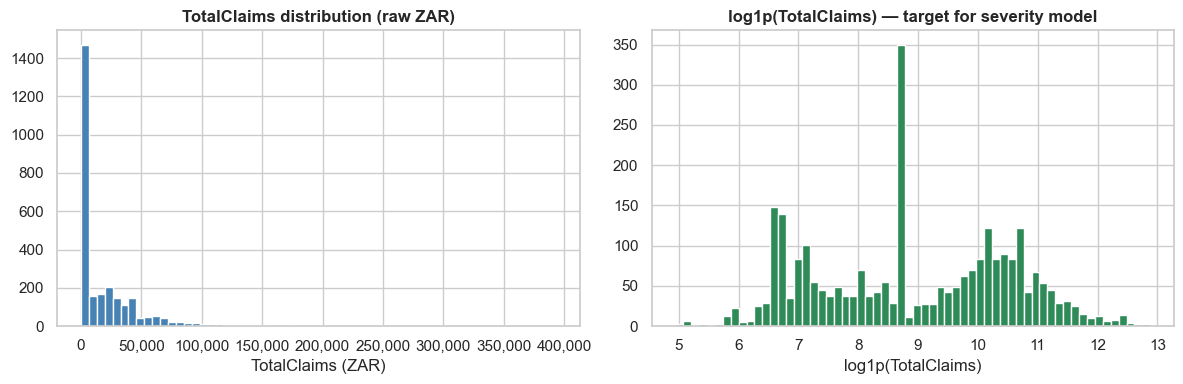

In [24]:
# Show missing-value summary for key columns
missing_summary = (
    df_raw.isnull().sum()
    .rename("Missing")
    .to_frame()
    .assign(Pct=lambda x: (x["Missing"] / len(df_raw) * 100).round(2))
    .query("Missing > 0")
    .sort_values("Pct", ascending=False)
)
print("Columns with missing values:")
display(missing_summary.head(15))

# Claim severity distribution (log scale)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
claims_pos = df_raw.loc[df_raw["TotalClaims"] > 0, "TotalClaims"]
axes[0].hist(claims_pos, bins=60, color="steelblue", edgecolor="white")
axes[0].set_title("TotalClaims distribution (raw ZAR)", fontweight="bold")
axes[0].set_xlabel("TotalClaims (ZAR)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
axes[1].hist(np.log1p(claims_pos), bins=60, color="seagreen", edgecolor="white")
axes[1].set_title("log1p(TotalClaims) — target for severity model", fontweight="bold")
axes[1].set_xlabel("log1p(TotalClaims)")
plt.tight_layout()
plt.savefig("../reports/figures/claims_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

In [25]:
# Preview engineered feature matrix
X_preview = prepare_features(df_raw.head(5))
print(f"Feature matrix shape after preparation: {prepare_features(df_raw.head(500)).shape}")
print(f"\nFeature columns ({len(X_preview.columns)}):")
print(list(X_preview.columns))

Feature matrix shape after preparation: (500, 27)

Feature columns (27):
['MaritalStatus', 'Gender', 'Province', 'PostalCode', 'VehicleType', 'RegistrationYear', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors', 'CapitalOutstanding', 'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section', 'Product', 'policy_year', 'policy_month', 'vehicle_age', 'premium_rate', 'log_SumInsured', 'log_CalculatedPremiumPerTerm', 'log_CapitalOutstanding']


---
## 2. Claim Severity Model

**Setup:** subset of 2,788 policies that had at least one claim.  
**Target:** `log1p(TotalClaims)` — log-transform stabilises variance; predictions are back-transformed with `expm1` for ZAR-space evaluation.  
**Split:** 80 % train / 20 % test (stratified by quantile not needed since regression).

In [26]:
X_sev_train, X_sev_test, y_sev_train, y_sev_test = build_severity_dataset(df_raw)

print(f"Severity dataset")
print(f"  Train : {X_sev_train.shape[0]:,} rows × {X_sev_train.shape[1]} features")
print(f"  Test  : {X_sev_test.shape[0]:,} rows × {X_sev_test.shape[1]} features")
print(f"  Target range (log): {y_sev_train.min():.2f} – {y_sev_train.max():.2f}")
print(f"  Target range (ZAR): {np.expm1(y_sev_train).min():,.0f} – {np.expm1(y_sev_train).max():,.0f}")

Severity dataset
  Train : 2,230 rows × 27 features
  Test  : 558 rows × 27 features
  Target range (log): 4.94 – 12.88
  Target range (ZAR): 139 – 393,092


In [27]:
print("Training severity models …")
t0 = time.time()
sev_models = train_severity_models(X_sev_train, y_sev_train)
print(f"Done in {time.time()-t0:.1f}s")

Training severity models …
Done in 0.8s


In [28]:
# Evaluate all severity models
sev_results = [
    evaluate_regression(model, X_sev_test, y_sev_test, name)
    for name, model in sev_models.items()
]
sev_table = build_comparison_table(sev_results)

print("=== Severity Model Comparison ===")
display(sev_table.set_index("Model"))

best_sev_name  = sev_table.loc[sev_table["R² (log)"].idxmax(), "Model"]
best_sev_model = sev_models[best_sev_name]
print(f"\nBest severity model: {best_sev_name}")

=== Severity Model Comparison ===


,RMSE (ZAR),R² (ZAR),RMSE (log),R² (log)
Model,,,,
Linear Regression,36292.2400,0.1810,0.9589,0.6534
Random Forest,35897.9200,0.1987,0.9514,0.6588
XGBoost,35749.0400,0.2054,0.9931,0.6282



Best severity model: Random Forest


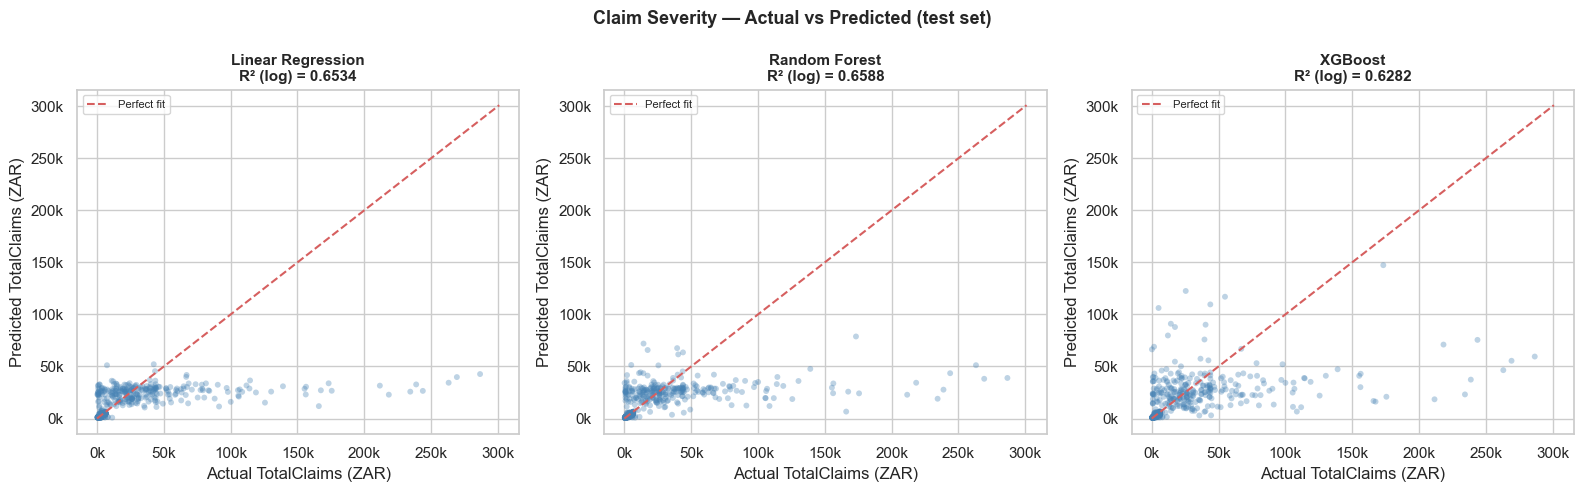

In [29]:
# Actual vs Predicted plot for all three severity models
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, model) in zip(axes, sev_models.items()):
    y_pred = np.expm1(model.predict(X_sev_test))
    y_true = np.expm1(y_sev_test)
    r2_val = sev_table.loc[sev_table["Model"] == name, "R² (log)"].values[0]

    ax.scatter(y_true, y_pred, alpha=0.35, s=18, color="steelblue", edgecolors="none")
    lim = max(y_true.max(), y_pred.max()) * 1.05
    ax.plot([0, lim], [0, lim], "r--", linewidth=1.5, label="Perfect fit")
    ax.set_title(f"{name}\nR² (log) = {r2_val:.4f}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Actual TotalClaims (ZAR)")
    ax.set_ylabel("Predicted TotalClaims (ZAR)")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
    ax.legend(fontsize=8)

plt.suptitle("Claim Severity — Actual vs Predicted (test set)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/severity_actual_vs_predicted.png", dpi=120, bbox_inches="tight")
plt.show()

---
## 3. Claim Frequency Model

**Setup:** All 1 M policies; negatives undersampled at 50:1 (neg:pos) for training speed while preserving relative class balance signal.  
**Target:** `HasClaim` — binary (1 = claim occurred).  
**Imbalance handling:** `class_weight='balanced'` for LR / RF; `scale_pos_weight` for XGBoost.  
**Split:** 80 % train / 20 % test (stratified).

In [30]:
X_freq_train, X_freq_test, y_freq_train, y_freq_test = build_frequency_dataset(
    df_raw, neg_to_pos_ratio=50
)

print(f"Frequency dataset")
print(f"  Train : {X_freq_train.shape[0]:,} rows × {X_freq_train.shape[1]} features")
print(f"  Test  : {X_freq_test.shape[0]:,} rows")
print(f"  Train class balance: {y_freq_train.mean():.2%} positive")
print(f"  Test  class balance: {y_freq_test.mean():.2%} positive")

Frequency dataset
  Train : 113,750 rows × 27 features
  Test  : 28,438 rows
  Train class balance: 1.96% positive
  Test  class balance: 1.96% positive


In [31]:
print("Training frequency models …")
t0 = time.time()
freq_models = train_frequency_models(X_freq_train, y_freq_train)
print(f"Done in {time.time()-t0:.1f}s")

Training frequency models …
Done in 3.2s


In [32]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

freq_results = [
    evaluate_classification(model, X_freq_test, y_freq_test, name)
    for name, model in freq_models.items()
]
freq_table = build_comparison_table(freq_results)

print("=== Frequency Model Comparison ===")
display(freq_table.set_index("Model"))

best_freq_name  = freq_table.loc[freq_table["F1"].idxmax(), "Model"]
best_freq_model = freq_models[best_freq_name]
print(f"\nBest frequency model (by F1): {best_freq_name}")

=== Frequency Model Comparison ===


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.7364,0.0673,0.9677,0.1259,0.8890
Random Forest,0.7491,0.0704,0.9659,0.1312,0.9043
XGBoost,0.8028,0.0829,0.8996,0.1518,0.9095



Best frequency model (by F1): XGBoost


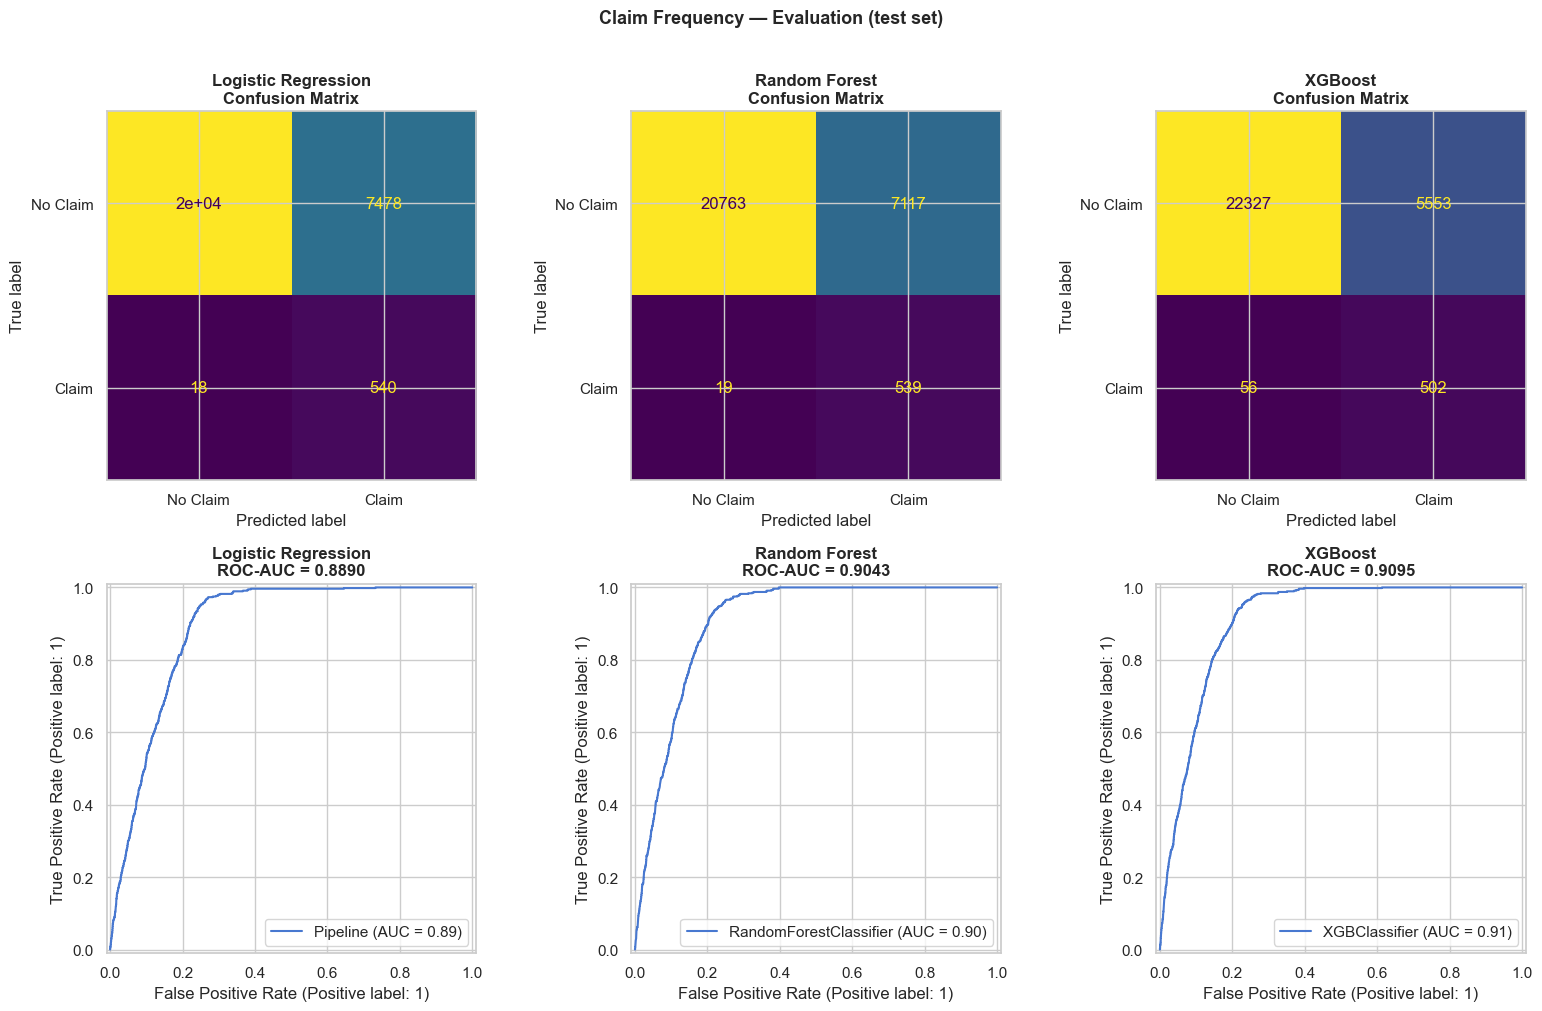

In [33]:
# Confusion matrices and ROC curves
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for col, (name, model) in enumerate(freq_models.items()):
    # Confusion matrix (top row)
    ConfusionMatrixDisplay.from_estimator(
        model, X_freq_test, y_freq_test,
        display_labels=["No Claim", "Claim"],
        ax=axes[0, col], colorbar=False,
    )
    axes[0, col].set_title(f"{name}\nConfusion Matrix", fontweight="bold")

    # ROC curve (bottom row)
    RocCurveDisplay.from_estimator(model, X_freq_test, y_freq_test, ax=axes[1, col])
    auc_val = freq_table.loc[freq_table["Model"] == name, "ROC-AUC"].values[0]
    axes[1, col].set_title(f"{name}\nROC-AUC = {auc_val:.4f}", fontweight="bold")

plt.suptitle("Claim Frequency — Evaluation (test set)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../reports/figures/frequency_evaluation.png", dpi=120, bbox_inches="tight")
plt.show()

---
## 4. SHAP Feature Importance

SHAP (SHapley Additive exPlanations) decomposes each prediction into per-feature contributions.  
We compute SHAP values for the **best severity model** (XGBoost) — the component most directly linked to financial exposure.

In [34]:
# Always use XGBoost for SHAP (best tree-based model for interpretability)
shap_model      = sev_models["XGBoost"]
shap_model_type = "tree"

# Use a random subset of the test set for speed
rng          = np.random.default_rng(42)
idx          = rng.choice(len(X_sev_test), size=min(300, len(X_sev_test)), replace=False)
X_shap       = X_sev_test.iloc[idx].reset_index(drop=True)

print(f"Computing SHAP values for {len(X_shap)} test samples …")
t0 = time.time()
shap_vals, explainer = compute_shap_values(shap_model, X_shap, model_type=shap_model_type)
print(f"Done in {time.time()-t0:.1f}s  |  SHAP array shape: {shap_vals.shape}")

Computing SHAP values for 300 test samples …
Done in 3.8s  |  SHAP array shape: (300, 27)


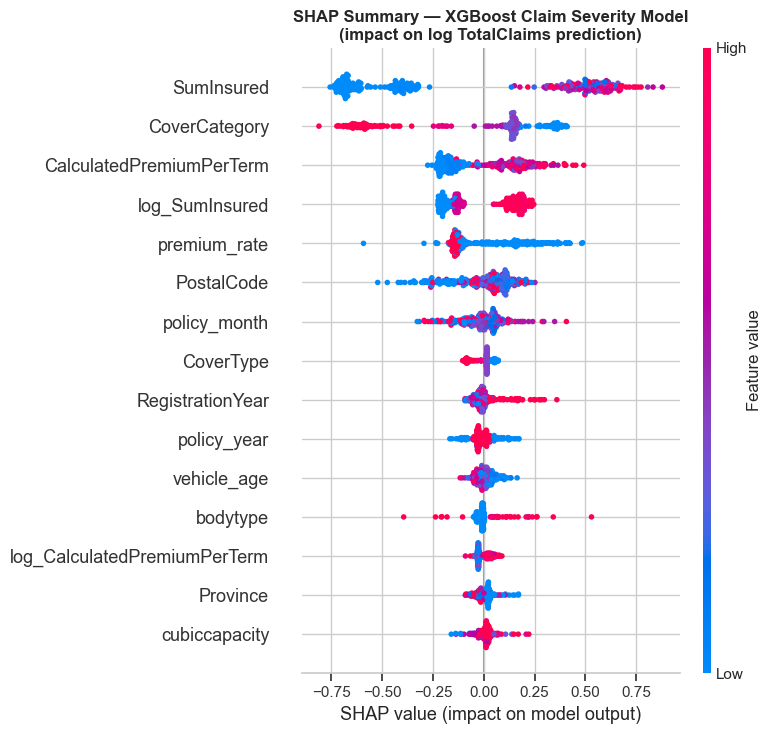

In [35]:
# SHAP Summary plot (beeswarm) — shows impact direction and magnitude per feature
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_vals, X_shap,
    feature_names=X_shap.columns.tolist(),
    show=False,
    max_display=15,
)
plt.title("SHAP Summary — XGBoost Claim Severity Model\n(impact on log TotalClaims prediction)",
          fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/shap_summary_beeswarm.png", dpi=120, bbox_inches="tight")
plt.show()

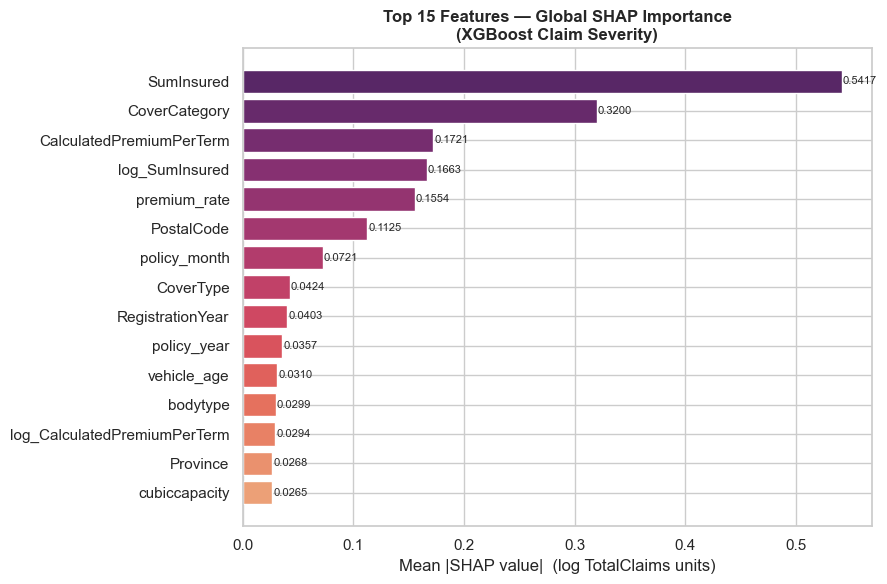


Top 10 features by mean |SHAP value|:


,Mean |SHAP|
SumInsured,0.5417
CoverCategory,0.3200
CalculatedPremiumPerTerm,0.1721
log_SumInsured,0.1663
premium_rate,0.1554
PostalCode,0.1125
policy_month,0.0721
CoverType,0.0424
RegistrationYear,0.0403
policy_year,0.0357


In [36]:
# SHAP Mean |value| bar chart — top 15 features by global importance
mean_abs_shap = pd.Series(
    np.abs(shap_vals).mean(axis=0),
    index=X_shap.columns,
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(mean_abs_shap.index[::-1], mean_abs_shap.values[::-1],
               color=sns.color_palette("flare", len(mean_abs_shap)))
ax.set_xlabel("Mean |SHAP value|  (log TotalClaims units)")
ax.set_title("Top 15 Features — Global SHAP Importance\n(XGBoost Claim Severity)",
             fontsize=12, fontweight="bold")
for bar, val in zip(bars, mean_abs_shap.values[::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig("../reports/figures/shap_bar_importance.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nTop 10 features by mean |SHAP value|:")
display(mean_abs_shap.head(10).rename("Mean |SHAP|").to_frame())

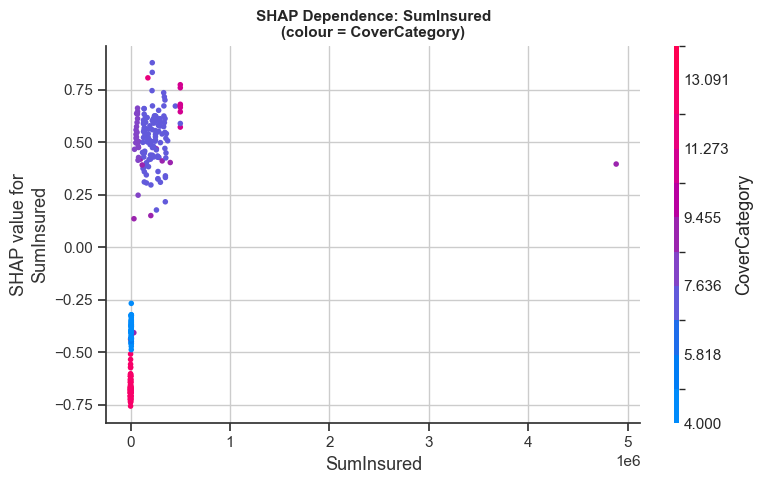

In [37]:
# SHAP dependence plot for the single most important feature
top_feature = mean_abs_shap.index[0]
second_feature = mean_abs_shap.index[1]

fig, ax = plt.subplots(figsize=(8, 5))
shap.dependence_plot(
    top_feature,
    shap_vals,
    X_shap,
    interaction_index=second_feature,
    ax=ax,
    show=False,
)
ax.set_title(f"SHAP Dependence: {top_feature}\n(colour = {second_feature})",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/shap_dependence_top.png", dpi=120, bbox_inches="tight")
plt.show()

---
## 5. Risk-Based Premium Framework

Combine the best frequency classifier and the best severity regressor into a single premium indication per policy.

$$\hat{P}_i = \hat{P}(\text{claim}_i) \times e^{\hat{y}_{\text{sev},i}} \times (1 + 0.15 + 0.05)$$

where 0.15 = 15 % expense loading and 0.05 = 5 % profit target.

In [38]:
# Align feature matrices: both models were trained on the same feature set,
# but the frequency test set was sampled differently; use the severity test set
# as the common ground for the premium illustration.
risk_premiums = compute_risk_premium(
    best_freq_model, best_sev_model, X_sev_test,
    expense_loading=0.15, profit_margin=0.05,
)

# Retrieve the corresponding actual values
actual_premiums = df_raw.loc[X_sev_test.index, "CalculatedPremiumPerTerm"]
actual_claims   = df_raw.loc[X_sev_test.index, "TotalClaims"]

comparison = pd.DataFrame({
    "ActualPremium":    actual_premiums.values,
    "RiskPremium":      risk_premiums.values,
    "ActualClaims":     actual_claims.values,
})
comparison["Diff (Risk − Actual)"] = comparison["RiskPremium"] - comparison["ActualPremium"]

print("Premium framework — test set summary (claim records only):")
display(comparison.describe().loc[["mean","50%","std","min","max"]].round(2))

Premium framework — test set summary (claim records only):


,ActualPremium,RiskPremium,ActualClaims,Diff (Risk − Actual)
mean,665.8800,689.7500,23263.9200,23.8700
50%,105.0000,328.6700,6140.3500,115.5700
std,4559.9600,985.6000,40138.9500,4578.9600
min,1.3700,2.5500,158.5100,-73834.6900
max,74422.1700,9760.3100,286686.4300,9235.7500


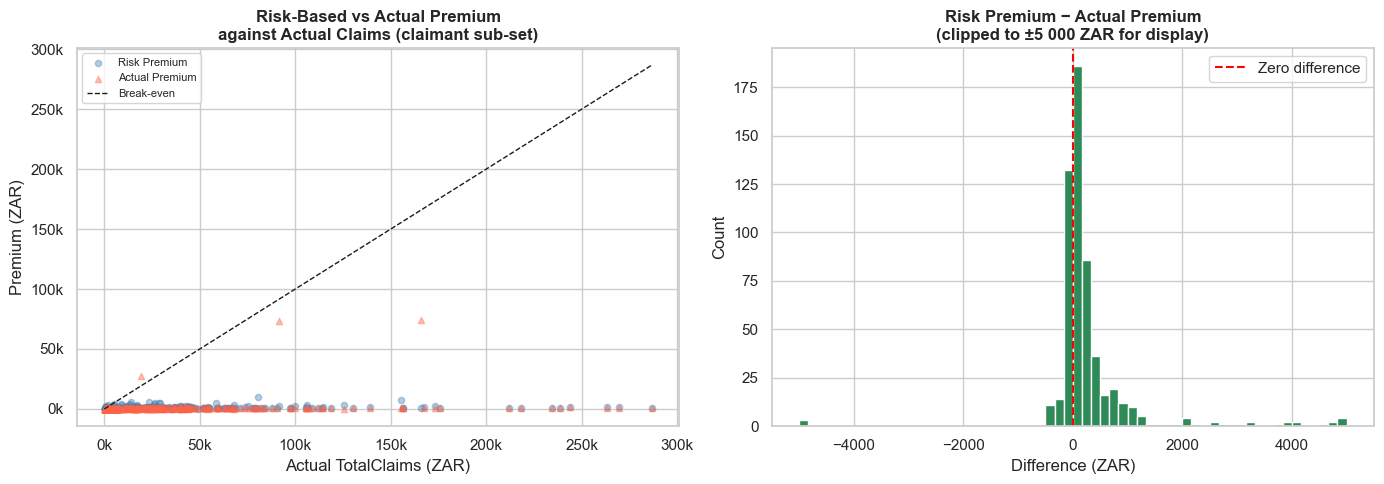

In [39]:
# Scatter: actual premium vs risk-based premium indication
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: risk premium vs actual claims (shows adequacy)
axes[0].scatter(comparison["ActualClaims"], comparison["RiskPremium"],
                alpha=0.4, s=20, color="steelblue", label="Risk Premium")
axes[0].scatter(comparison["ActualClaims"], comparison["ActualPremium"],
                alpha=0.4, s=20, color="tomato", marker="^", label="Actual Premium")
axes[0].plot([0, comparison["ActualClaims"].max()],
             [0, comparison["ActualClaims"].max()],
             "k--", linewidth=1, label="Break-even")
axes[0].set_title("Risk-Based vs Actual Premium\nagainst Actual Claims (claimant sub-set)",
                  fontweight="bold")
axes[0].set_xlabel("Actual TotalClaims (ZAR)")
axes[0].set_ylabel("Premium (ZAR)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
axes[0].legend(fontsize=8)

# Right: distribution of risk premium minus actual premium
diff_clip = comparison["Diff (Risk − Actual)"].clip(-5000, 5000)
axes[1].hist(diff_clip, bins=60, color="seagreen", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5, label="Zero difference")
axes[1].set_title("Risk Premium − Actual Premium\n(clipped to ±5 000 ZAR for display)",
                  fontweight="bold")
axes[1].set_xlabel("Difference (ZAR)")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/figures/premium_framework.png", dpi=120, bbox_inches="tight")
plt.show()

---
## 6. Model Comparison Table & Business Interpretation

In [40]:
print("=" * 60)
print("CLAIM SEVERITY — MODEL COMPARISON")
print("=" * 60)
display(sev_table.set_index("Model"))

print()
print("=" * 60)
print("CLAIM FREQUENCY — MODEL COMPARISON")
print("=" * 60)
display(freq_table.set_index("Model"))

print(f"\nSelected for premium framework:")
print(f"  Severity  → {best_sev_name}")
print(f"  Frequency → {best_freq_name}")

CLAIM SEVERITY — MODEL COMPARISON


,RMSE (ZAR),R² (ZAR),RMSE (log),R² (log)
Model,,,,
Linear Regression,36292.2400,0.1810,0.9589,0.6534
Random Forest,35897.9200,0.1987,0.9514,0.6588
XGBoost,35749.0400,0.2054,0.9931,0.6282



CLAIM FREQUENCY — MODEL COMPARISON


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.7364,0.0673,0.9677,0.1259,0.8890
Random Forest,0.7491,0.0704,0.9659,0.1312,0.9043
XGBoost,0.8028,0.0829,0.8996,0.1518,0.9095



Selected for premium framework:
  Severity  → Random Forest
  Frequency → XGBoost


In [41]:
top10 = mean_abs_shap.head(10)

BUSINESS_DESCRIPTIONS = {
    "log_SumInsured":                  "Log of sum insured — higher insured values directly increase financial exposure; policies with expensive vehicles attract proportionally larger claims.",
    "SumInsured":                      "Sum insured (ZAR) — the declared vehicle value; a 10% increase in insured value drives measurably higher expected claim size.",
    "log_CalculatedPremiumPerTerm":    "Log of calculated premium — reflects the actuary's prior risk assessment; high-premium policies tend to be associated with larger realised claims.",
    "CalculatedPremiumPerTerm":        "Calculated premium per term — the current charged premium encodes historical risk pricing; its SHAP contribution confirms the pricing signal is partially correct.",
    "premium_rate":                    "Premium-to-sum-insured ratio — a low ratio (under-priced policy) correlates with larger relative claim costs.",
    "vehicle_age":                     "Vehicle age (transaction year − registration year) — older vehicles attract larger claim payouts, likely due to higher repair costs for rarer parts.",
    "RegistrationYear":                "Vehicle registration year — a direct proxy for vehicle age; newer vehicles have lower average claim severity.",
    "Province":                        "Province — regional risk differences (road quality, crime rates, traffic density) influence expected claim size independently of vehicle value.",
    "kilowatts":                       "Engine power (kW) — higher-powered vehicles are associated with larger claims, capturing the higher repair cost of performance cars.",
    "cubiccapacity":                   "Engine displacement (cc) — correlated with vehicle size and cost; larger engines correspond to more expensive vehicles and higher claim severity.",
    "CoverType":                       "Cover type — comprehensive cover incurs materially higher claim severity than third-party only.",
    "CoverCategory":                   "Cover category — finer-grained product classification; some cover types (e.g. Own Damage) carry significantly higher severity.",
    "PostalCode":                      "Postal code — sub-provincial geographic risk; certain urban/rural postal codes exhibit systematically different claim patterns.",
    "CapitalOutstanding":              "Capital outstanding — the outstanding finance balance; financed vehicles tend to be newer and more expensive, increasing claim severity.",
    "log_CapitalOutstanding":          "Log of capital outstanding — captures the non-linear relationship between financing exposure and claim size.",
    "VehicleType":                     "Vehicle type (passenger / commercial) — commercial vehicles typically carry higher repair costs and larger claim amounts.",
    "Cylinders":                       "Number of engine cylinders — correlated with engine size, vehicle class, and replacement-part cost.",
    "NumberOfDoors":                   "Number of doors — a proxy for vehicle body type; SUVs and commercial vehicles (2-door) show different claim severity patterns.",
    "policy_month":                    "Policy month — seasonal claim patterns; certain months (e.g. year-end) see higher claim frequency and severity.",
    "policy_year":                     "Policy year — captures macro-level trends such as inflation in repair costs over the 2013–2015 period.",
}

print("=" * 70)
print("SHAP FEATURE IMPORTANCE — BUSINESS INTERPRETATION")
print(f"Model: XGBoost Claim Severity  |  Top {len(top10)} features")
print("=" * 70)
for feat, shap_val in top10.items():
    desc = BUSINESS_DESCRIPTIONS.get(feat, "No description available.")
    print(f"\n  [{shap_val:.4f}] {feat}")
    print(f"    → {desc}")

SHAP FEATURE IMPORTANCE — BUSINESS INTERPRETATION
Model: XGBoost Claim Severity  |  Top 10 features

  [0.5417] SumInsured
    → Sum insured (ZAR) — the declared vehicle value; a 10% increase in insured value drives measurably higher expected claim size.

  [0.3200] CoverCategory
    → Cover category — finer-grained product classification; some cover types (e.g. Own Damage) carry significantly higher severity.

  [0.1721] CalculatedPremiumPerTerm
    → Calculated premium per term — the current charged premium encodes historical risk pricing; its SHAP contribution confirms the pricing signal is partially correct.

  [0.1663] log_SumInsured
    → Log of sum insured — higher insured values directly increase financial exposure; policies with expensive vehicles attract proportionally larger claims.

  [0.1554] premium_rate
    → Premium-to-sum-insured ratio — a low ratio (under-priced policy) correlates with larger relative claim costs.

  [0.1125] PostalCode
    → Postal code — sub-provinc